# 07 - XGBoost Forecasting Model

## Analytical Objectives

- Load the feature-engineered Walmart dataset.
- Prepare the dataset for machine learning.
- Preserve chronological order during train-test splitting.
- Train an XGBoost regression model.
- Use historical, temporal, store, department, holiday, and economic features.
- Generate weekly sales predictions.
- Evaluate forecasting performance using MAE, RMSE, and MAPE.
- Analyze actual versus predicted sales.
- Analyze residual errors.
- Identify the most important predictive features.
- Compare XGBoost against the Naïve Baseline and Prophet models.
- Save the trained model and predictions.

## Expected Outcome

By the end of this notebook, we will have:

- A trained XGBoost forecasting model.
- Forecasted Walmart weekly sales.
- Model performance metrics.
- Feature importance analysis.
- Comparison against previous forecasting approaches.

#### Install XGBoost

#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

#### Load Feature Engineered Dataset

In [2]:
train = pd.read_csv(
    "../data/processed/train_feature_engineered.csv"
)

train["Date"] = pd.to_datetime(train["Date"])

train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,...,Dept_Sales_Rank,Dept_Sales_Contribution,Month_Sin,Month_Cos,Week_Sin,Week_Cos,Quarter_Sin,Quarter_Cos,DayOfWeek_Sin,DayOfWeek_Cos
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,0.0,...,21,1.83516,0.866025,5.000000e-01,0.568065,0.822984,1.0,6.123234e-17,-0.433884,-0.900969
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,0.0,...,21,1.83516,0.866025,5.000000e-01,0.663123,0.748511,1.0,6.123234e-17,-0.433884,-0.900969
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,0.0,...,21,1.83516,0.866025,5.000000e-01,0.748511,0.663123,1.0,6.123234e-17,-0.433884,-0.900969
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,0.0,...,21,1.83516,0.866025,5.000000e-01,0.822984,0.568065,1.0,6.123234e-17,-0.433884,-0.900969
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,0.0,...,21,1.83516,1.000000,6.123234e-17,0.885456,0.464723,1.0,6.123234e-17,-0.433884,-0.900969


In [3]:
train.shape

(421570, 66)

In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 66 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Store                    421570 non-null  int64         
 1   Dept                     421570 non-null  int64         
 2   Date                     421570 non-null  datetime64[us]
 3   Weekly_Sales             421570 non-null  float64       
 4   IsHoliday                421570 non-null  bool          
 5   Type                     421570 non-null  str           
 6   Size                     421570 non-null  int64         
 7   Temperature              421570 non-null  float64       
 8   Fuel_Price               421570 non-null  float64       
 9   MarkDown1                421570 non-null  float64       
 10  MarkDown2                421570 non-null  float64       
 11  MarkDown3                421570 non-null  float64       
 12  MarkDown4                42

#### Sort Chronologically

In [5]:
train = train.sort_values(
    ["Date", "Store", "Dept"]
).reset_index(drop=True)

In [6]:
train[
    ["Date", "Store", "Dept", "Weekly_Sales"]
].head(10)

,Date,Store,Dept,Weekly_Sales
0,2010-02-05,1,1,24924.50
1,2010-02-05,1,2,50605.27
2,2010-02-05,1,3,13740.12
3,2010-02-05,1,4,39954.04
4,2010-02-05,1,5,32229.38
5,2010-02-05,1,6,5749.03
6,2010-02-05,1,7,21084.08
7,2010-02-05,1,8,40129.01
8,2010-02-05,1,9,16930.99
9,2010-02-05,1,10,30721.50


#### Define Target

In [7]:
target = "Weekly_Sales"

#### Select Features

In [8]:
feature_columns = [
    
    # Store / Department identifiers
    "Store",
    "Dept",
    
    # Date features
    "Year",
    "Quarter",
    "Month",
    "Week",
    "Day",
    "DayOfWeek",
    "IsWeekend",
    
    # Holiday features
    "Holiday_Flag",
    "Previous_Holiday",
    "Next_Holiday",
    "Near_Holiday",
    
    # External variables
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    
    # Lag features
    "Lag_1",
    "Lag_2",
    "Lag_4",
    "Lag_8",
    "Lag_12",
    "Lag_52",
    
    # Rolling features
    "Rolling_Mean_4",
    "Rolling_Mean_8",
    "Rolling_Mean_12",
    "Rolling_Std_4",
    "Rolling_Std_8",
    "Rolling_Std_12",
    "Rolling_Min_4",
    "Rolling_Max_4",
    
    # Expanding features
    "Expanding_Mean",
    "Expanding_Std",
    "Expanding_Min",
    "Expanding_Max",
    
    # Store features
    "Store_Avg_Sales",
    "Store_Std_Sales",
    "Store_Min_Sales",
    "Store_Max_Sales",
    "Store_Sales_Rank",
    "Store_Type",
    "Store_Size_Relative",
    
    # Department features
    "Dept_Avg_Sales",
    "Dept_Std_Sales",
    "Dept_Min_Sales",
    "Dept_Max_Sales",
    "Dept_Sales_Rank",
    "Dept_Sales_Contribution",
    
    # Cyclical features
    "Month_Sin",
    "Month_Cos",
    "Week_Sin",
    "Week_Cos",
    "Quarter_Sin",
    "Quarter_Cos",
    "DayOfWeek_Sin",
    "DayOfWeek_Cos"
]

#### Create X and y

In [9]:
X = train[feature_columns]

y = train[target]

In [10]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (421570, 56)
y Shape: (421570,)


#### Time-Based Train-Test Split

In [11]:
split_date = pd.Timestamp("2012-06-01")

In [12]:
#Training data:

train_mask = train["Date"] < split_date

In [13]:
#Testing data:

test_mask = train["Date"] >= split_date

In [14]:
#Create datasets:

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

#### Verify Split

In [15]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (356489, 56)
X_test : (65081, 56)
y_train: (356489,)
y_test : (65081,)


In [16]:
#Check dates:

print(
    "Training:",
    train.loc[train_mask, "Date"].min(),
    "to",
    train.loc[train_mask, "Date"].max()
)

print(
    "Testing:",
    train.loc[test_mask, "Date"].min(),
    "to",
    train.loc[test_mask, "Date"].max()
)

Training: 2010-02-05 00:00:00 to 2012-05-25 00:00:00
Testing: 2012-06-01 00:00:00 to 2012-10-26 00:00:00


#### Build XGBoost Model

In [17]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

In [18]:
#Train XGBoost

xgb_model.fit(
    X_train,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


#### Generate Predictions

In [19]:
xgb_predictions = xgb_model.predict(
    X_test
)

In [20]:
xgb_predictions[:10]

array([17168.44 , 49252.7  ,  8814.381, 42708.004, 19112.322,  4931.535,
       36678.41 , 40235.992, 32299.404, 37848.734], dtype=float32)

#### Create Prediction DataFrame

In [21]:
xgb_results = train.loc[
    test_mask,
    [
        "Date",
        "Store",
        "Dept",
        "Weekly_Sales"
    ]
].copy()

In [22]:
#Add predictions:

xgb_results["Predicted_Sales"] = (
    xgb_predictions
)

In [23]:
xgb_results.head(10)

,Date,Store,Dept,Weekly_Sales,Predicted_Sales
356489,2012-06-01,1,1,16065.49,17168.439453
356490,2012-06-01,1,2,47425.29,49252.699219
356491,2012-06-01,1,3,7175.77,8814.380859
356492,2012-06-01,1,4,41566.55,42708.003906
356493,2012-06-01,1,5,17233.25,19112.322266
356494,2012-06-01,1,6,3249.75,4931.535156
356495,2012-06-01,1,7,31568.92,36678.410156
356496,2012-06-01,1,8,41039.74,40235.992188
356497,2012-06-01,1,9,35001.66,32299.404297
356498,2012-06-01,1,10,37294.14,37848.734375


#### Calculate MAE, RMSE, MAPE

In [24]:
xgb_mae = mean_absolute_error(
    xgb_results["Weekly_Sales"],
    xgb_results["Predicted_Sales"]
)

print(
    f"XGBoost MAE: {xgb_mae:,.2f}"
)

XGBoost MAE: 1,200.49


In [25]:
xgb_rmse = np.sqrt(
    mean_squared_error(
        xgb_results["Weekly_Sales"],
        xgb_results["Predicted_Sales"]
    )
)

print(
    f"XGBoost RMSE: {xgb_rmse:,.2f}"
)

XGBoost RMSE: 2,602.18


In [26]:
xgb_mape = (
    mean_absolute_percentage_error(
        xgb_results["Weekly_Sales"],
        xgb_results["Predicted_Sales"]
    ) * 100
)

print(
    f"XGBoost MAPE: {xgb_mape:.2f}%"
)

XGBoost MAPE: 18133494391951776.00%


#### XGBoost Performance Summary

In [27]:
xgb_summary = pd.DataFrame({
    "Model": ["XGBoost"],
    "MAE": [xgb_mae],
    "RMSE": [xgb_rmse],
    "MAPE": [xgb_mape]
})

xgb_summary

,Model,MAE,RMSE,MAPE
0,XGBoost,1200.494662,2602.177309,1.813349e+16


#### Actual vs Predicted Sales

In [28]:
weekly_xgb = (
    xgb_results
    .groupby("Date")
    .agg(
        Actual_Sales=("Weekly_Sales", "sum"),
        Predicted_Sales=("Predicted_Sales", "sum")
    )
    .reset_index()
)

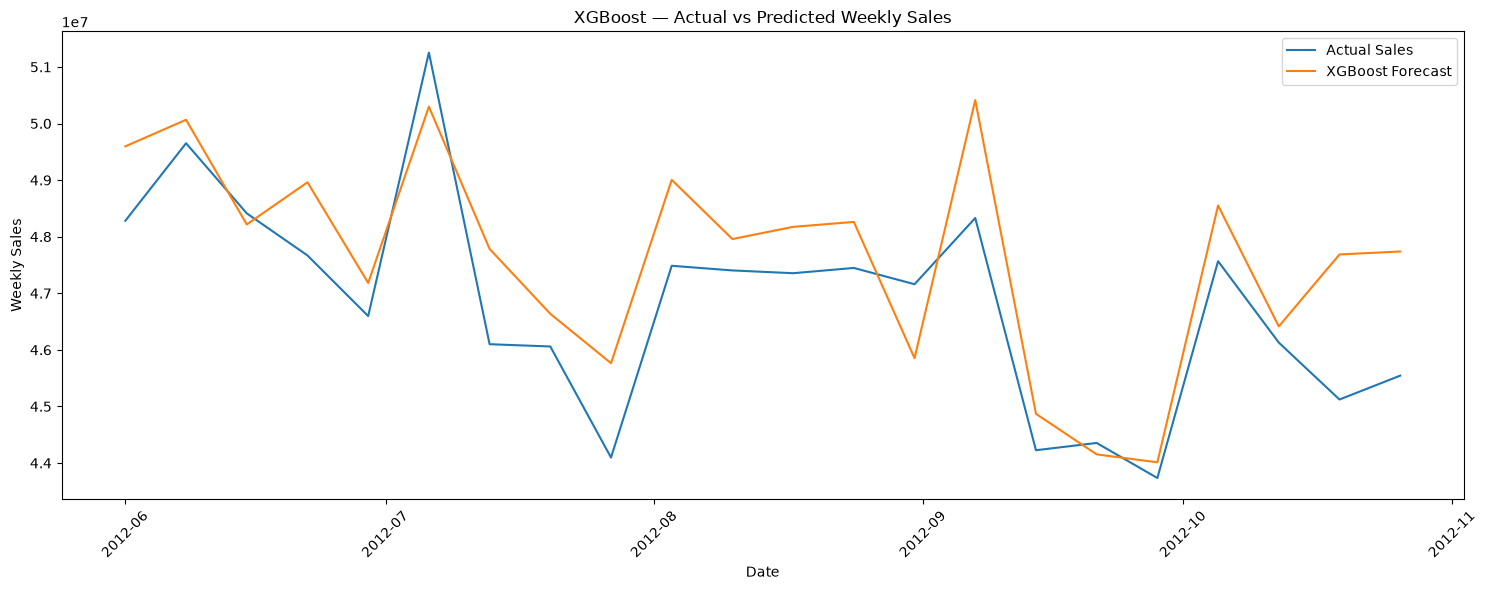

In [29]:
#Plot:

plt.figure(figsize=(15, 6))

plt.plot(
    weekly_xgb["Date"],
    weekly_xgb["Actual_Sales"],
    label="Actual Sales"
)

plt.plot(
    weekly_xgb["Date"],
    weekly_xgb["Predicted_Sales"],
    label="XGBoost Forecast"
)

plt.title(
    "XGBoost — Actual vs Predicted Weekly Sales"
)

plt.xlabel("Date")
plt.ylabel("Weekly Sales")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Residual Analysis

In [30]:
#Create residuals:

xgb_results["Residual"] = (
    xgb_results["Weekly_Sales"]
    - xgb_results["Predicted_Sales"]
)

In [31]:
#Inspect:

xgb_results[
    [
        "Date",
        "Store",
        "Dept",
        "Weekly_Sales",
        "Predicted_Sales",
        "Residual"
    ]
].head(10)

,Date,Store,Dept,Weekly_Sales,Predicted_Sales,Residual
356489,2012-06-01,1,1,16065.49,17168.439453,-1102.949453
356490,2012-06-01,1,2,47425.29,49252.699219,-1827.409219
356491,2012-06-01,1,3,7175.77,8814.380859,-1638.610859
356492,2012-06-01,1,4,41566.55,42708.003906,-1141.453906
356493,2012-06-01,1,5,17233.25,19112.322266,-1879.072266
356494,2012-06-01,1,6,3249.75,4931.535156,-1681.785156
356495,2012-06-01,1,7,31568.92,36678.410156,-5109.490156
356496,2012-06-01,1,8,41039.74,40235.992188,803.747812
356497,2012-06-01,1,9,35001.66,32299.404297,2702.255703
356498,2012-06-01,1,10,37294.14,37848.734375,-554.594375


In [32]:
#Residual Statistics

xgb_results["Residual"].describe()

count     65081.000000
mean       -270.647262
std        2588.084181
min     -124561.533125
25%        -682.106084
50%        -101.925241
75%         308.041445
max       62763.189844
Name: Residual, dtype: float64

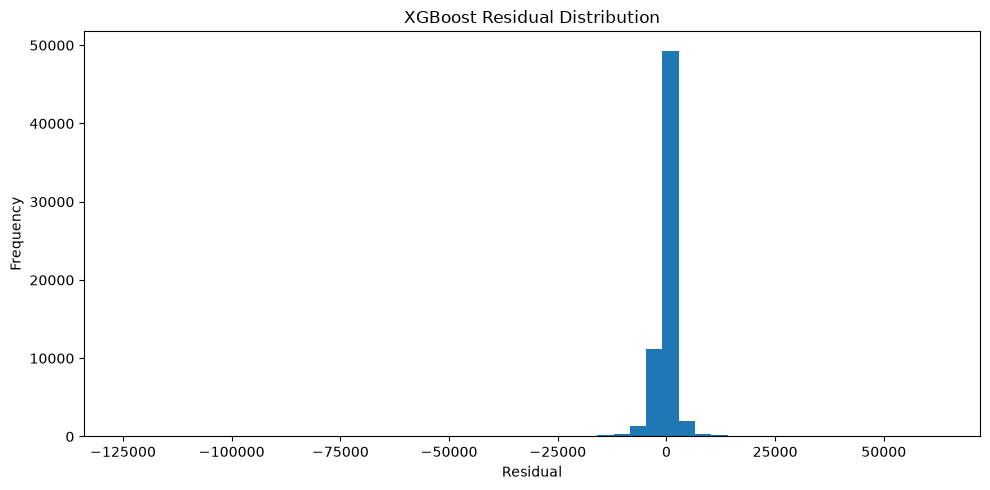

In [33]:
#Residual Distribution

plt.figure(figsize=(10, 5))

plt.hist(
    xgb_results["Residual"],
    bins=50
)

plt.title(
    "XGBoost Residual Distribution"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

#### Largest Errors

In [34]:
#Largest Underpredictions

xgb_results.nlargest(
    10,
    "Residual"
)[
    [
        "Date",
        "Store",
        "Dept",
        "Weekly_Sales",
        "Predicted_Sales",
        "Residual"
    ]
]

,Date,Store,Dept,Weekly_Sales,Predicted_Sales,Residual
398664,2012-09-07,13,3,114230.60,51467.410156,62763.189844
366803,2012-06-22,22,11,60650.80,15372.252930,45278.547070
392743,2012-08-24,13,5,73550.30,34544.972656,39005.327344
379649,2012-07-20,38,38,100618.04,61888.867188,38729.172812
358802,2012-06-01,35,11,76321.27,37607.949219,38713.320781
383654,2012-08-03,10,3,120827.95,82446.992188,38380.957812
367671,2012-06-22,35,11,53862.26,18956.580078,34905.679922
404033,2012-09-21,4,72,127832.24,93498.156250,34334.083750
366942,2012-06-22,24,11,49812.14,17222.732422,32589.407578
395705,2012-08-31,13,3,91139.25,61076.355469,30062.894531


In [35]:
#Largest Overpredictions

xgb_results.nsmallest(
    10,
    "Residual"
)[
    [
        "Date",
        "Store",
        "Dept",
        "Weekly_Sales",
        "Predicted_Sales",
        "Residual"
    ]
]

,Date,Store,Dept,Weekly_Sales,Predicted_Sales,Residual
419558,2012-10-26,14,72,63071.17,187632.703125,-124561.533125
416606,2012-10-19,14,72,69389.31,177785.015625,-108395.705625
417025,2012-10-19,20,72,63571.41,158613.671875,-95042.261875
398797,2012-09-07,14,90,102944.90,156918.484375,-53973.584375
392741,2012-08-24,13,3,73306.98,119758.859375,-46451.879375
420185,2012-10-26,23,72,51421.23,96567.046875,-45145.816875
413640,2012-10-12,14,92,156174.21,198890.218750,-42716.008750
415785,2012-10-19,2,72,52176.54,92774.046875,-40597.506875
392873,2012-08-24,14,90,85339.29,124427.468750,-39088.178750
407695,2012-09-28,14,92,139707.80,177040.546875,-37332.746875


#### Feature Importance

In [36]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": xgb_model.feature_importances_
})

In [37]:
#Sort:

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

In [38]:
#Display the top 20:

feature_importance.head(20)

,Feature,Importance
17,Lag_1,0.459218
23,Rolling_Mean_4,0.128597
31,Expanding_Mean,0.092273
18,Lag_2,0.087030
29,Rolling_Min_4,0.042956
19,Lag_4,0.016659
9,Holiday_Flag,0.014427
46,Dept_Sales_Rank,0.012787
22,Lag_52,0.009854
4,Month,0.009455


#### Visualize Feature Importance

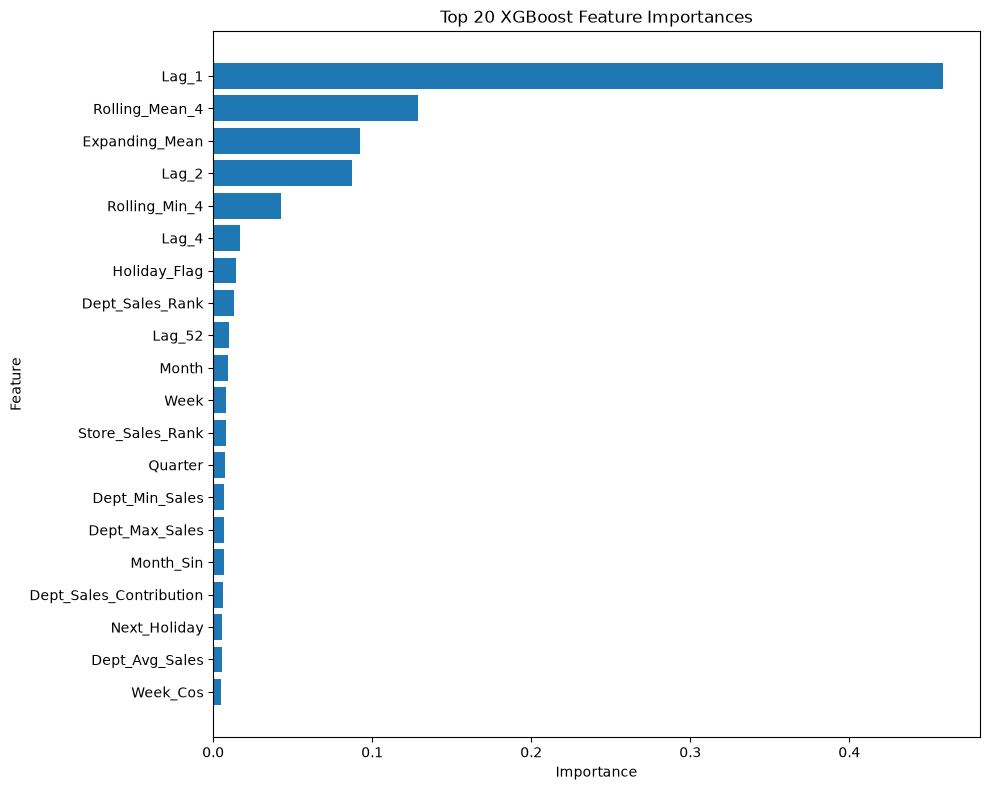

In [39]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title(
    "Top 20 XGBoost Feature Importances"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

#### Compare Models

In [40]:
#Load Baseline Model
baseline_results = pd.read_csv(
    "../reports/figures/baseline_results.csv"
)

baseline_results

,Model,MAE,RMSE,MAPE
0,Naive Baseline,1540.862076,3476.166405,5.397247e+15


In [41]:
#Load prophet summary

prophet_summary=pd.read_csv(
    "../reports/figures/prophet_summary.csv"
)

In [42]:
#XGBoost:

XGBoost_model_comparison = pd.concat(
    [
        baseline_results,
        prophet_summary,
        xgb_summary
    ],
    ignore_index=True
)

In [43]:
XGBoost_model_comparison

,Model,MAE,RMSE,MAPE,Unnamed: 0
0,Naive Baseline,1.540862e+03,3.476166e+03,5.397247e+15,NaN
1,Prophet,1.385515e+06,1.838681e+06,2.945324e+00,0.0
2,XGBoost,1.200495e+03,2.602177e+03,1.813349e+16,NaN


In [44]:
#Sort by MAE

XGBoost_model_comparison.sort_values(
    "MAE"
)

,Model,MAE,RMSE,MAPE,Unnamed: 0
2,XGBoost,1.200495e+03,2.602177e+03,1.813349e+16,NaN
0,Naive Baseline,1.540862e+03,3.476166e+03,5.397247e+15,NaN
1,Prophet,1.385515e+06,1.838681e+06,2.945324e+00,0.0


In [45]:
#Sort by RMSE

XGBoost_model_comparison.sort_values(
    "RMSE"
)

,Model,MAE,RMSE,MAPE,Unnamed: 0
2,XGBoost,1.200495e+03,2.602177e+03,1.813349e+16,NaN
0,Naive Baseline,1.540862e+03,3.476166e+03,5.397247e+15,NaN
1,Prophet,1.385515e+06,1.838681e+06,2.945324e+00,0.0


#### Save Predictions

In [46]:
xgb_summary.to_csv(
    "../reports/figures/xgb_summary.csv",
    index=False
)

In [47]:
xgb_results.to_csv(
    "../data/processed/xgb_predictions.csv",
    index=False
)

#### Save Feature Importance

In [48]:
feature_importance.to_csv(
    "../reports/figures/xgb_feature_importance.csv",
    index=False
)

#### Save Model Comparison

In [51]:
XGBoost_model_comparison.to_csv(
    "../reports/figures/XGBoost_model_comparison.csv",
    index=False
)

In [52]:
import joblib

joblib.dump(
    xgb_model,
    "../models/xgboost_model.pkl"
)

['../models/xgboost_model.pkl']

### Key Observations

- XGBoost successfully incorporated historical, temporal, holiday, store, department, and external economic features.
- The model was trained using a chronological train-test split to preserve the forecasting structure of the problem.
- Lag and rolling features allow XGBoost to learn recent demand patterns.
- Store and department features allow the model to account for differences in sales behavior across Walmart locations and departments.
- Feature importance analysis identifies the variables that contribute most strongly to sales predictions.
- XGBoost performance should be compared directly with the Naïve Baseline and Prophet using MAE and RMSE.
- The model provides a more flexible framework than Prophet because it can simultaneously incorporate many explanatory variables.

### Business Insight

XGBoost combines historical sales patterns with operational, seasonal, store-level, department-level, and economic information.

This makes it particularly suitable for Walmart sales forecasting because demand is influenced by more than historical sales alone. The model can learn relationships between recent demand, store characteristics, holidays, economic conditions, and department behavior.

Feature importance analysis also provides an opportunity to identify the strongest drivers of sales, supporting both forecasting and business decision-making.

### Executive Summary

The XGBoost model represents the first advanced machine-learning approach in the Walmart Sales Forecasting project.

Unlike the Naïve Baseline and Prophet models, XGBoost uses the extensive feature engineering completed in Notebook 04. These features include historical sales lags, rolling statistics, expanding statistics, calendar variables, holiday indicators, store characteristics, department characteristics, cyclical variables, and external economic factors.

The model was evaluated using a chronological holdout period to simulate real-world future forecasting. MAE, RMSE, and MAPE were calculated, with MAE and RMSE serving as the primary evaluation metrics.

XGBoost performance will be compared against the Naïve Baseline and Prophet. If XGBoost produces lower forecasting errors, this indicates that combining historical sales patterns with additional business and external variables provides greater predictive power.

The next stage will introduce LightGBM, another gradient-boosting algorithm that can provide a strong alternative to XGBoost while offering efficient training on large datasets.